<a href="https://colab.research.google.com/github/Moaazhe74/CIFAR10-CNN-AE-VAE-GANs/blob/main/CIFAR10_(Deep_Learning_Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***1. Project Introduction***

This project applies different Deep Learning techniques to the CIFAR-10 image dataset.  
The objective is to build a complete Deep Learning portfolio that includes image classification, optimizer comparison, image reconstruction, and image generation.

The project consists of three main parts:

1. **Image Classification**
   - Build a Convolutional Neural Network (CNN) to classify CIFAR-10 images into 10 different classes.
   - Train the same CNN architecture using different optimizers.
   - Compare the performance of Adam and SGD with Momentum.

2. **Image Reconstruction**
   - Build a Convolutional Autoencoder or Variational Autoencoder.
   - Compress the input images into a latent representation.
   - Reconstruct the original images and evaluate the reconstruction quality.

3. **Image Generation**
   - Use a generative model such as a Variational Autoencoder or GAN.
   - Generate new images similar to the CIFAR-10 dataset.
   - Compare original, reconstructed, and generated images.

The models will be evaluated using training loss, validation loss, accuracy, reconstruction loss, and visual inspection of the generated images.

---

## Dataset

The **CIFAR-10 dataset** contains 60,000 colored images with a size of `32 × 32` pixels.

The dataset is divided into:

- 50,000 training images.
- 10,000 testing images.
- 10 different image classes.

The classes are:

`Airplane`, `Automobile`, `Bird`, `Cat`, `Deer`, `Dog`, `Frog`, `Horse`, `Ship`, and `Truck`.

# ***2. Imports and Setup***

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tarfile
import pickle

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models,layers,callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam,SGD

import warnings
warnings.filterwarnings('ignore')

# ***3. Load CIFAR-10 Dataset***

In [2]:
DataSetGoogleDrivePath = '/content/drive/MyDrive/DataSets/cifar-10-python.tar.gz'

extract_dir = "/content/drive/MyDrive/DataSets"

dataset_dir = os.path.join(
    extract_dir,
    "cifar-10-batches-py"
)

if os.path.exists(dataset_dir):
    print("Dataset is already extracted.")
    print("Dataset directory:", dataset_dir)

else:
    print("Extracting CIFAR-10 dataset...")

    with tarfile.open(DataSetGoogleDrivePath, mode="r:gz") as tar:
        tar.extractall(path=extract_dir)

    print("Dataset extracted successfully.")
    print("Dataset directory:", dataset_dir)

Dataset is already extracted.
Dataset directory: /content/drive/MyDrive/DataSets/cifar-10-batches-py


In [3]:
def load_cifar_batch(file_path):

    with open(file_path, "rb") as file:
        batch = pickle.load(file, encoding="bytes")

    images = batch[b"data"]
    labels = batch[b"labels"]


    images = images.reshape(-1, 3, 32, 32)


    images = images.transpose(0, 2, 3, 1)


    labels = np.array(labels).reshape(-1, 1)

    return images, labels



In [4]:
train_images = []
train_labels = []

for batch_number in range(1, 6):

    batch_path = os.path.join(
        dataset_dir,
        f"data_batch_{batch_number}"
    )

    images, labels = load_cifar_batch(batch_path)

    train_images.append(images)
    train_labels.append(labels)

    print(
        f"Batch {batch_number} loaded:",
        images.shape,
        labels.shape
    )
x_train = np.concatenate(train_images, axis=0)
y_train = np.concatenate(train_labels, axis=0)



test_batch_path = os.path.join(dataset_dir,"test_batch")
x_test, y_test = load_cifar_batch(test_batch_path)

Batch 1 loaded: (10000, 32, 32, 3) (10000, 1)
Batch 2 loaded: (10000, 32, 32, 3) (10000, 1)
Batch 3 loaded: (10000, 32, 32, 3) (10000, 1)
Batch 4 loaded: (10000, 32, 32, 3) (10000, 1)
Batch 5 loaded: (10000, 32, 32, 3) (10000, 1)


In [5]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [6]:
print("\nImage data type:", x_train.dtype)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())


Image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [7]:
meta_path = os.path.join(dataset_dir, "batches.meta")

with open(meta_path, "rb") as file:
    meta_data = pickle.load(file, encoding="bytes")

class_names = [
    class_name.decode("utf-8")
    for class_name in meta_data[b"label_names"]
]

print("CIFAR-10 Classes:\n")

for label, class_name in enumerate(class_names):
    print(f"{label}: {class_name}")

CIFAR-10 Classes:

0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


# ***4. Data Exploration***

## **4.1 Representing 20 random samples**

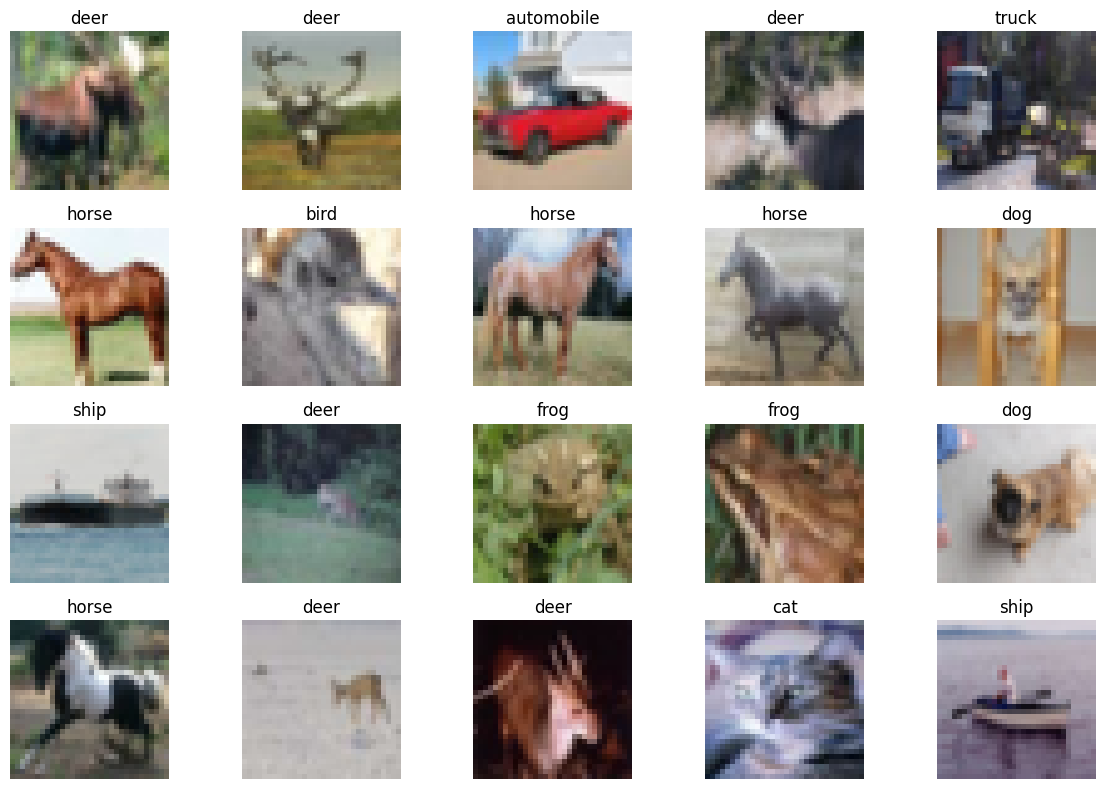

In [8]:
number_of_images = 20

random_indices = np.random.choice(
    len(x_train),
    size=number_of_images,
    replace=False
)

plt.figure(figsize=(12, 8))

for position, image_index in enumerate(random_indices):

    plt.subplot(4, 5, position + 1)

    plt.imshow(x_train[image_index])

    label = y_train[image_index][0]

    plt.title(class_names[label])

    plt.axis("off")

plt.tight_layout()
plt.show()

## **4.2 Classes Distripution**

In [9]:
unique_labels, class_counts = np.unique(
    y_train,
    return_counts=True
)

print("Training class distribution:\n")

for label, count in zip(unique_labels, class_counts):
    print(f"{label} - {class_names[label]}: {count} images")

Training class distribution:

0 - airplane: 5000 images
1 - automobile: 5000 images
2 - bird: 5000 images
3 - cat: 5000 images
4 - deer: 5000 images
5 - dog: 5000 images
6 - frog: 5000 images
7 - horse: 5000 images
8 - ship: 5000 images
9 - truck: 5000 images


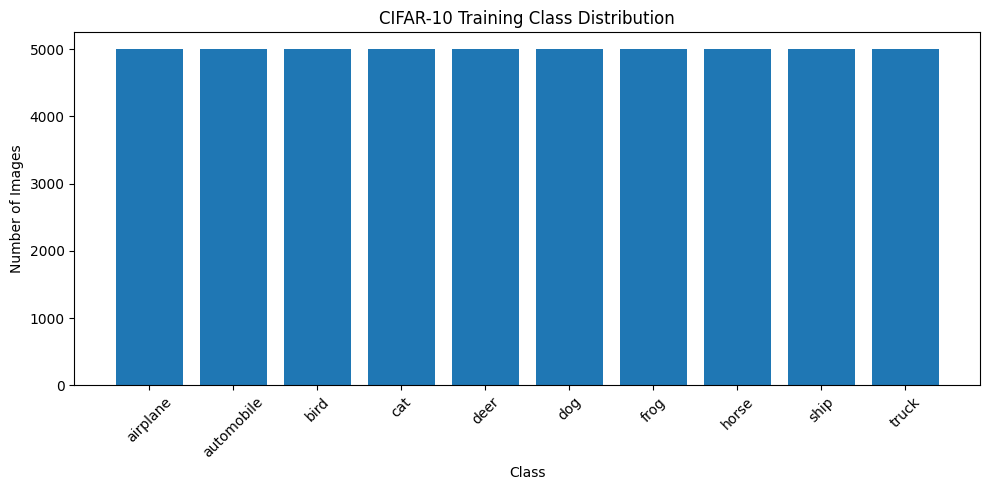

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(class_names, class_counts)

plt.title("CIFAR-10 Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ***5. Data Preprocessing***

In [11]:
x_train_original = x_train.copy()
x_test_original = x_test.copy()

y_train_original = y_train.copy()
y_test_original = y_test.copy()

## **5.1 Normalization & change dtype**

In [12]:
x_train=x_train.astype('float32')
y_train=y_train.astype('float32')

x_train=x_train/255.0
x_test=x_test/255.0

## **5.2 Labels Reshape**

In [13]:
y_test=y_test.reshape(-1)
y_train=y_train.reshape(-1)

## **5.3 Validation Set Separation**

In [14]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

# ***6. CNN Classification Model***

## **6.1 Build CNN model**

In [15]:
input_shape = (32, 32, 3)
number_of_classes = len(class_names)

def build_cnn_model():
    model = models.Sequential(
        [
            # Input layer
            layers.Input(shape=input_shape),

            # First convolutional block
            layers.Conv2D(
                filters=32,
                kernel_size=(3, 3),
                padding="same",
                activation="relu"
            ),

            layers.MaxPooling2D(
                pool_size=(2, 2)
            ),

            layers.Dropout(0.25),

            # Second convolutional block
            layers.Conv2D(
                filters=64,
                kernel_size=(3, 3),
                padding="same",
                activation="relu"
            ),

            layers.MaxPooling2D(
                pool_size=(2, 2)
            ),

            layers.Dropout(0.25),

            # Third convolutional block
            layers.Conv2D(
                filters=128,
                kernel_size=(3, 3),
                padding="same",
                activation="relu"
            ),

            layers.MaxPooling2D(
                pool_size=(2, 2)
            ),

            layers.Dropout(0.25),

            # Convert feature maps into one vector
            layers.Flatten(),

            # Fully connected layer
            layers.Dense(
                units=128,
                activation="relu"
            ),

            layers.Dropout(0.5),

            # Output layer
            layers.Dense(
                units=number_of_classes,
                activation="softmax"
            )
        ],
        name="CIFAR10_CNN"
    )

    return model

In [16]:
cnn_template = build_cnn_model()

print("CNN model created successfully.")

CNN model created successfully.


In [17]:
cnn_template.summary()


Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## **6.2 construct constant intial weights**

In [18]:
initial_weights = cnn_template.get_weights()

print("Initial model weights saved.")

Initial model weights saved.


# ***7. Adam Training***

## **7.1 build ADAM model & add intial weghts**

In [19]:
adam_model = build_cnn_model()

adam_model.set_weights(initial_weights)

print("Adam model created with the same initial weights.")

Adam model created with the same initial weights.


## **7.2 construct optimizer ,loss & metrics for ADAM model**

In [20]:
adam_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Adam model compiled successfully.")

Adam model compiled successfully.


## **7.3 construct early stopping for ADAM model**

In [21]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## **7.4 ADAM model fitting**

In [22]:
adam_history = adam_model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3459 - loss: 1.7734 - val_accuracy: 0.4966 - val_loss: 1.3941
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4865 - loss: 1.4225 - val_accuracy: 0.5824 - val_loss: 1.2243
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5410 - loss: 1.2827 - val_accuracy: 0.6116 - val_loss: 1.0949
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5821 - loss: 1.1802 - val_accuracy: 0.6554 - val_loss: 0.9938
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6075 - loss: 1.1109 - val_accuracy: 0.6724 - val_loss: 0.9225
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6292 - loss: 1.0584 - val_accuracy: 0.6926 - val_loss: 0.8726
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6474 - loss: 1.0044 - val_accuracy: 0.7066 - val_loss: 0.8272
Epoch 8/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6585 - loss: 0.9771 - val_ac

## **7.5 initial evaluation and representaion for ADAM model scores**

In [23]:
adam_test_loss, adam_test_accuracy = adam_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Adam Test Loss:", adam_test_loss)
print("Adam Test Accuracy:", adam_test_accuracy)

Adam Test Loss: 0.6705267429351807
Adam Test Accuracy: 0.76910001039505


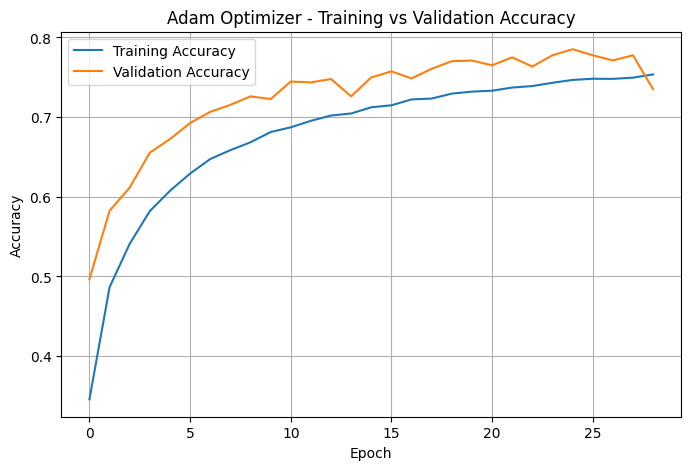

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(adam_history.history["accuracy"], label="Training Accuracy")
plt.plot(adam_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Adam Optimizer - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)
plt.show()

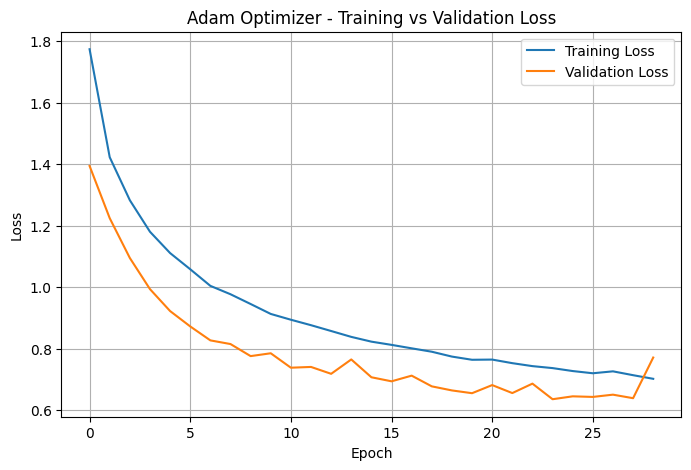

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(adam_history.history["loss"], label="Training Loss")
plt.plot(adam_history.history["val_loss"], label="Validation Loss")

plt.title("Adam Optimizer - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.show()

# ***8. SGD with Momentum Training***

## **8.1 build SGD with momentum model & add intial weghts**

In [26]:
sgd_model = build_cnn_model()

sgd_model.set_weights(initial_weights)

print("SGD model created with the same initial weights.")

SGD model created with the same initial weights.


## **8.2 construct optimizer ,loss & metrics for SGD with momentum model**

In [27]:
sgd_model.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("SGD model compiled successfully.")

SGD model compiled successfully.


8.3 construct early stopping for SGD with momentum model

In [28]:
sgd_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## **8.4 SGD with momentum model fitting**

In [29]:
sgd_history = sgd_model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[sgd_early_stopping],
    verbose=1
)

Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.2659 - loss: 1.9766 - val_accuracy: 0.3976 - val_loss: 1.6957
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4144 - loss: 1.5977 - val_accuracy: 0.5046 - val_loss: 1.4060
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4806 - loss: 1.4401 - val_accuracy: 0.5354 - val_loss: 1.2732
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5210 - loss: 1.3277 - val_accuracy: 0.6076 - val_loss: 1.1316
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5521 - loss: 1.2462 - val_accuracy: 0.6262 - val_loss: 1.0723
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5793 - loss: 1.1829 - val_accuracy: 0.6542 - val_loss: 0.9820
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5950 - loss: 1.1347 - val_accuracy: 0.6184 - val_loss: 1.1064
Epoch 8/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6190 - loss: 1.0839 - val_ac

## **8.5 initial evaluation and representaion for SGD with momentum model scores**

In [30]:
sgd_test_loss, sgd_test_accuracy = sgd_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("SGD Test Loss:", sgd_test_loss)
print("SGD Test Accuracy:", sgd_test_accuracy)

SGD Test Loss: 0.737236499786377
SGD Test Accuracy: 0.7430999875068665


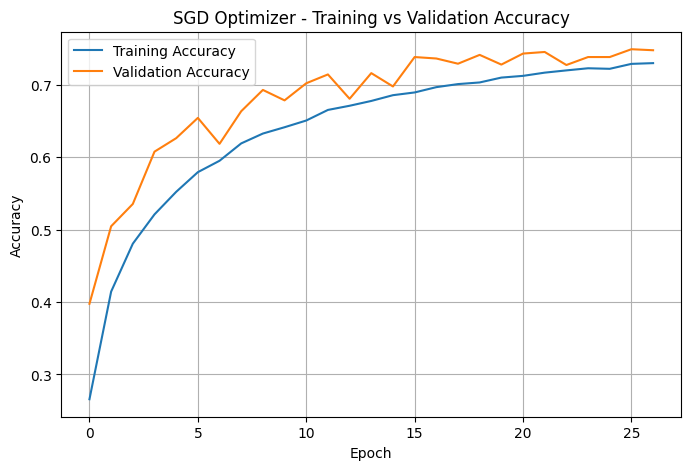

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    sgd_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    sgd_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("SGD Optimizer - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)
plt.show()

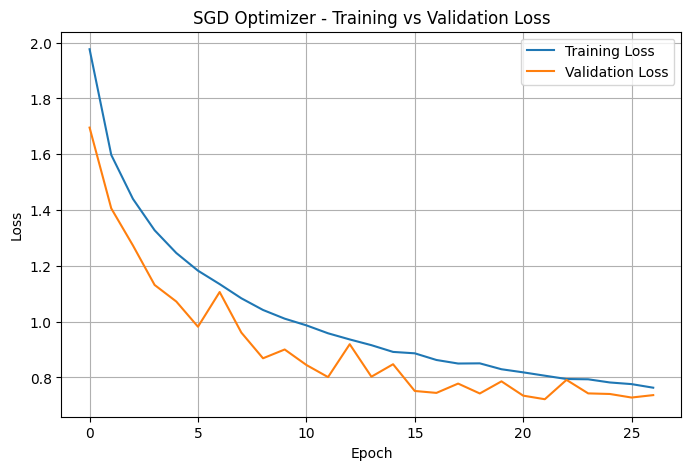

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    sgd_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    sgd_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("SGD Optimizer - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.show()

# ***9. Optimizer Comparison***

## **9.1 Results comparison**

In [33]:
optimizer_results = pd.DataFrame({
    "Optimizer": ["Adam", "SGD with Momentum"],
    "Test Loss": [adam_test_loss, sgd_test_loss],
    "Test Accuracy": [adam_test_accuracy, sgd_test_accuracy]
})

optimizer_results

,Optimizer,Test Loss,Test Accuracy
0,Adam,0.670527,0.7691
1,SGD with Momentum,0.737236,0.7431


## **9.2 Test Accuracy Comparison**

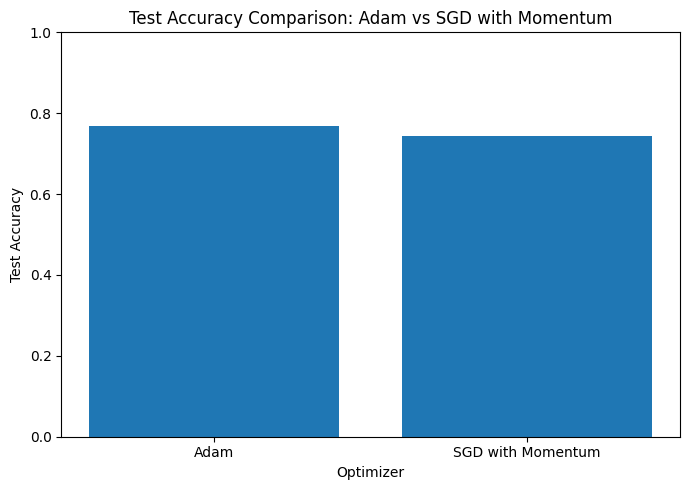

In [34]:
plt.figure(figsize=(7, 5))

plt.bar(
    optimizer_results["Optimizer"],
    optimizer_results["Test Accuracy"]
)

plt.title("Test Accuracy Comparison: Adam vs SGD with Momentum")
plt.xlabel("Optimizer")
plt.ylabel("Test Accuracy")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## **9.3 Test Loss Comparison**

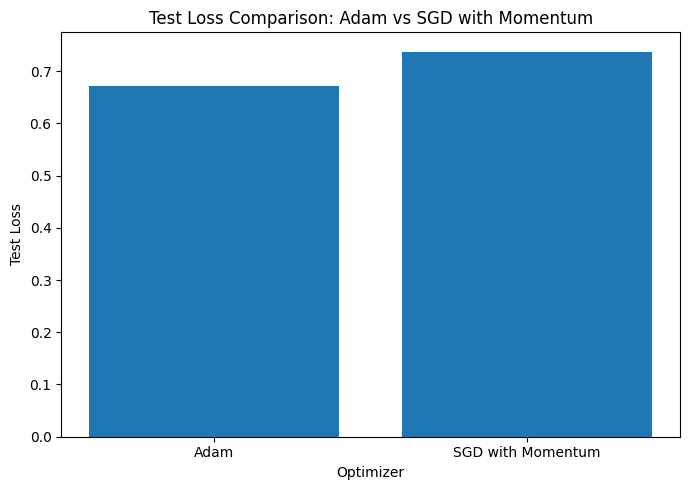

In [35]:
plt.figure(figsize=(7, 5))

plt.bar(
    optimizer_results["Optimizer"],
    optimizer_results["Test Loss"]
)

plt.title("Test Loss Comparison: Adam vs SGD with Momentum")
plt.xlabel("Optimizer")
plt.ylabel("Test Loss")

plt.tight_layout()
plt.show()

## **9.4 Validation Accuracy Comparison**

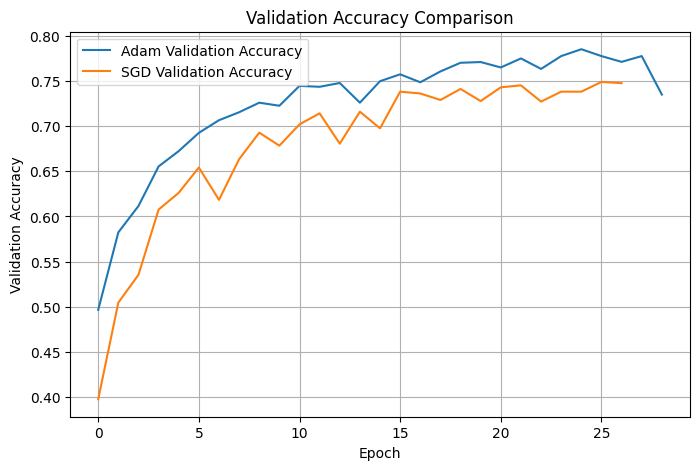

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    adam_history.history["val_accuracy"],
    label="Adam Validation Accuracy"
)

plt.plot(
    sgd_history.history["val_accuracy"],
    label="SGD Validation Accuracy"
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()

## **9.5 Validation Loss Comparison**

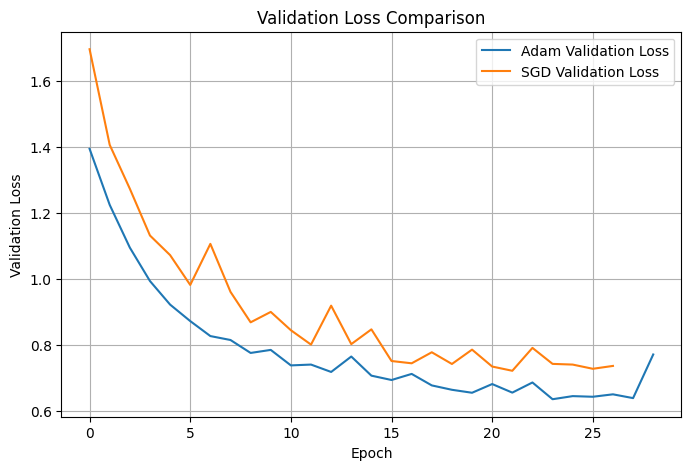

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    adam_history.history["val_loss"],
    label="Adam Validation Loss"
)

plt.plot(
    sgd_history.history["val_loss"],
    label="SGD Validation Loss"
)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

## **9.6 Best optimizer is ADAM**

In [38]:
best_optimizer_index = optimizer_results["Test Accuracy"].idxmax()

best_optimizer = optimizer_results.loc[best_optimizer_index, "Optimizer"]
best_accuracy = optimizer_results.loc[best_optimizer_index, "Test Accuracy"]
best_loss = optimizer_results.loc[best_optimizer_index, "Test Loss"]

print("Best Optimizer:", best_optimizer)
print("Best Test Accuracy:", best_accuracy)
print("Best Test Loss:", best_loss)

Best Optimizer: Adam
Best Test Accuracy: 0.76910001039505
Best Test Loss: 0.6705267429351807


## **9.7 apply ADAM model classification on test data**

### **9.7.1 ADAM model predication**

In [39]:
y_pred_probabilities = adam_model.predict(x_test)

print("Prediction probabilities shape:", y_pred_probabilities.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Prediction probabilities shape: (10000, 10)


In [40]:
y_pred = np.argmax(y_pred_probabilities, axis=1)

print("Predicted labels shape:", y_pred.shape)
print("First 10 predicted labels:", y_pred[:10])
print("First 10 true labels:", y_test[:10])

Predicted labels shape: (10000,)
First 10 predicted labels: [3 8 8 0 6 6 1 4 3 1]
First 10 true labels: [3 8 8 0 6 6 1 6 3 1]


### **9.7.2 ADAM model classification report**

In [41]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

    airplane       0.79      0.79      0.79      1000
  automobile       0.88      0.90      0.89      1000
        bird       0.70      0.61      0.65      1000
         cat       0.66      0.51      0.58      1000
        deer       0.67      0.79      0.72      1000
         dog       0.68      0.67      0.68      1000
        frog       0.77      0.87      0.82      1000
       horse       0.79      0.82      0.81      1000
        ship       0.85      0.88      0.87      1000
       truck       0.87      0.84      0.86      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



<Figure size 1000x800 with 0 Axes>

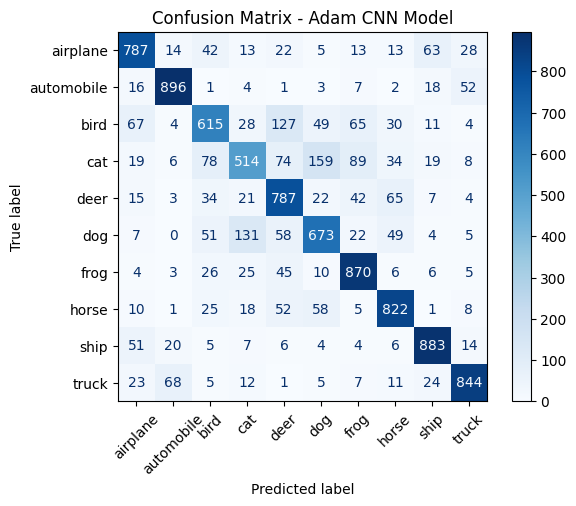

In [42]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Adam CNN Model")
plt.show()

### **9.7.3 represinting 20 random images**

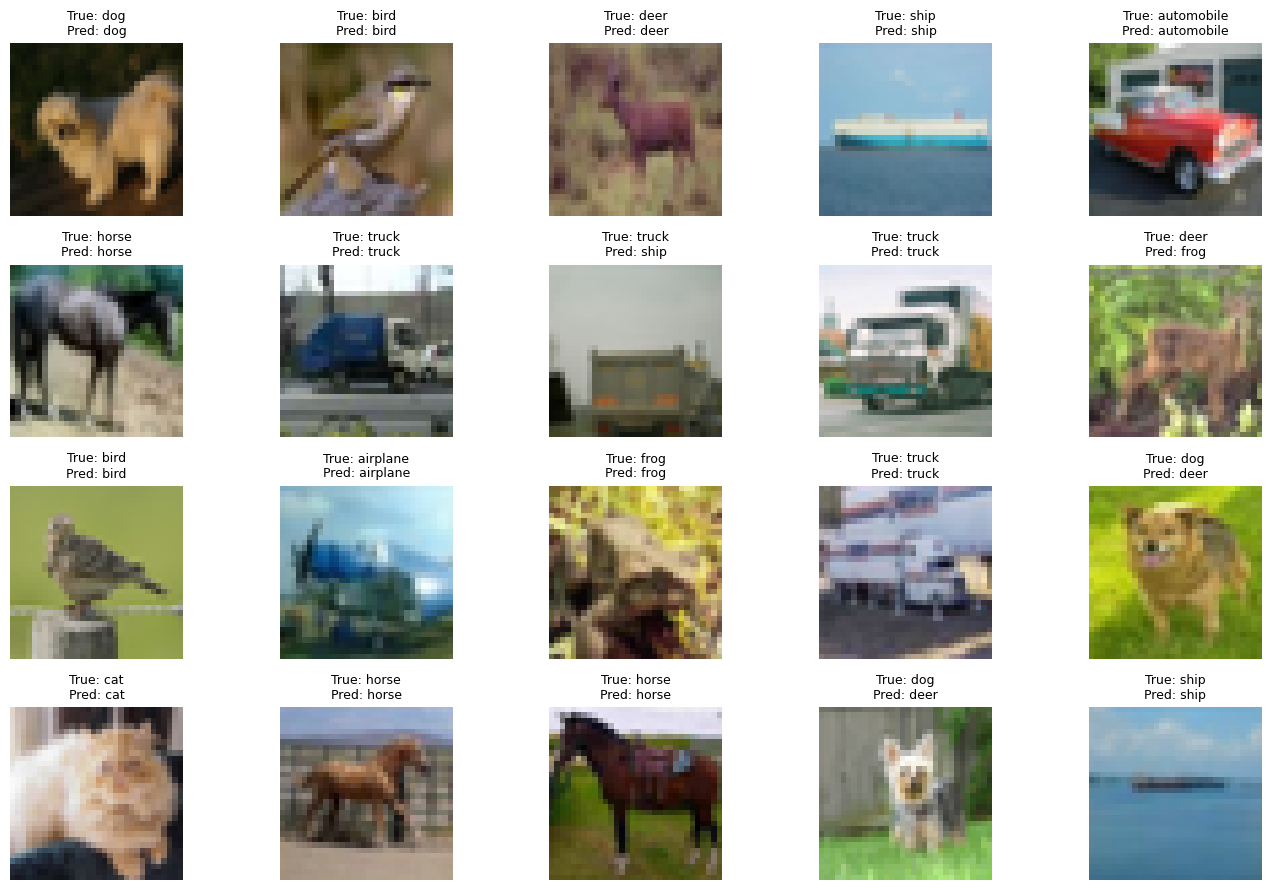

In [43]:
number_of_images = 20

random_indices = np.random.choice(
    len(x_test),
    size=number_of_images,
    replace=False
)

plt.figure(figsize=(14, 9))

for position, image_index in enumerate(random_indices):

    plt.subplot(4, 5, position + 1)

    plt.imshow(x_test[image_index])

    true_label = y_test[image_index]
    predicted_label = y_pred[image_index]

    true_class = class_names[true_label]
    predicted_class = class_names[predicted_label]

    title = f"True: {true_class}\nPred: {predicted_class}"

    plt.title(title, fontsize=9)

    plt.axis("off")

plt.tight_layout()
plt.show()

### **9.7.4 representing 20 incorrect predictions**

Number of incorrect predictions: 2309
Number of correct predictions: 7691


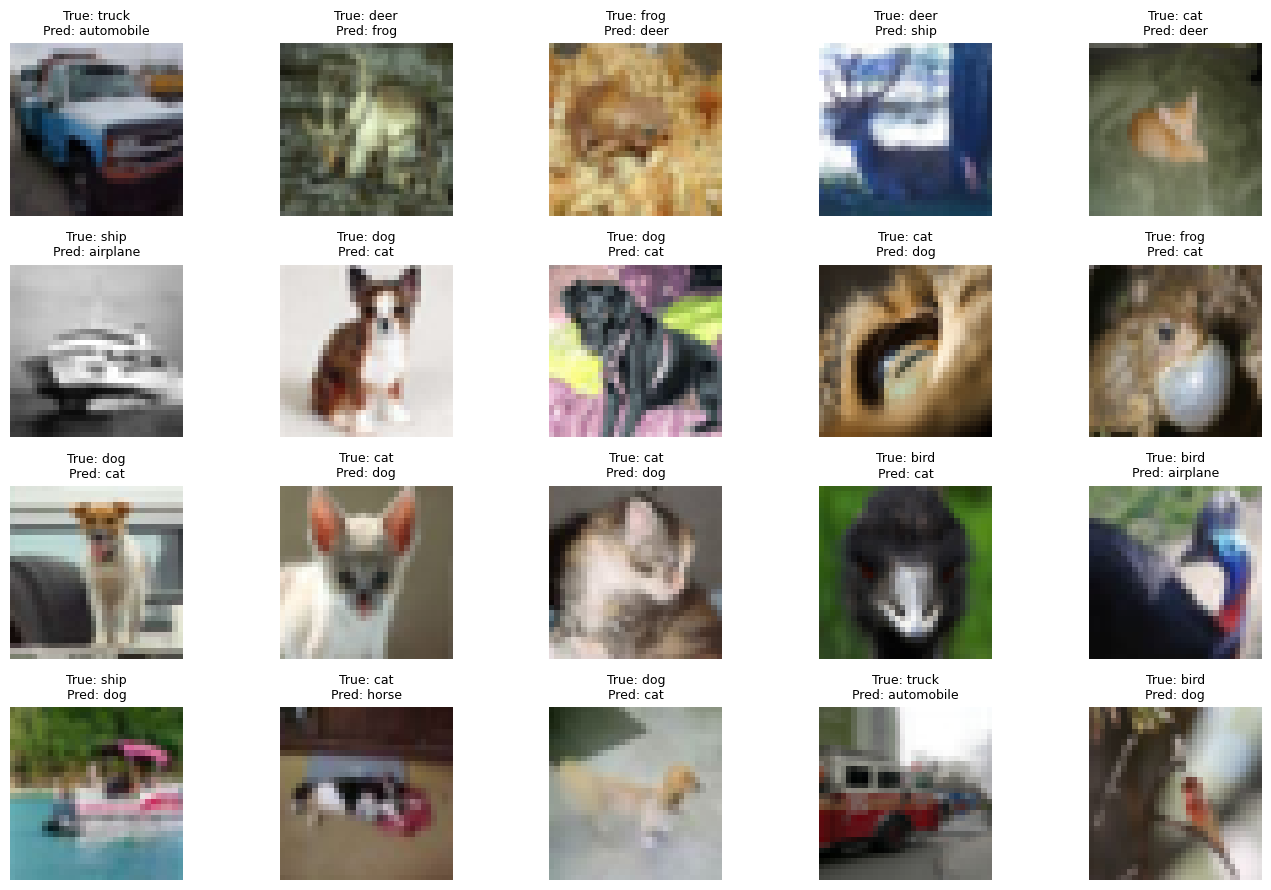

In [44]:
incorrect_indices = np.where(y_test != y_pred)[0]

print("Number of incorrect predictions:", len(incorrect_indices))
print("Number of correct predictions:", len(y_test) - len(incorrect_indices))

number_of_images = 20

sample_incorrect_indices = np.random.choice(
    incorrect_indices,
    size=number_of_images,
    replace=False
)

plt.figure(figsize=(14, 9))

for position, image_index in enumerate(sample_incorrect_indices):

    plt.subplot(4, 5, position + 1)

    plt.imshow(x_test[image_index])

    true_label = y_test[image_index]
    predicted_label = y_pred[image_index]

    true_class = class_names[true_label]
    predicted_class = class_names[predicted_label]

    title = f"True: {true_class}\nPred: {predicted_class}"

    plt.title(title, fontsize=9)

    plt.axis("off")

plt.tight_layout()
plt.show()

### **9.7.5 Saving ADAM model to drive**

In [45]:
model_save_path = "/content/drive/MyDrive/Saved Models/best_cifar10_adam_model.keras"

adam_model.save(model_save_path)

print("Best model saved to:", model_save_path)

Best model saved to: /content/drive/MyDrive/Saved Models/best_cifar10_adam_model.keras


# ***10. Autoencoder***

## **10.1 Defining Autoencoder**

In [46]:
def build_autoencoder():
    # Encoder
    input_img = layers.Input(shape=(32, 32, 3), name="encoder_input")

    x = layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )(input_img)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        padding="same"
    )(x)

    x = layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        padding="same"
    )(x)

    x = layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )(x)

    encoded = layers.MaxPooling2D(
        pool_size=(2, 2),
        padding="same",
        name="latent_representation"
    )(x)

    # Decoder
    x = layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )(encoded)

    x = layers.UpSampling2D(
        size=(2, 2)
    )(x)

    x = layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )(x)

    x = layers.UpSampling2D(
        size=(2, 2)
    )(x)

    x = layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    )(x)

    x = layers.UpSampling2D(
        size=(2, 2)
    )(x)

    decoded = layers.Conv2D(
        filters=3,
        kernel_size=(3, 3),
        activation="sigmoid",
        padding="same",
        name="decoder_output"
    )(x)

    autoencoder = models.Model(
        inputs=input_img,
        outputs=decoded,
        name="CIFAR10_Convolutional_Autoencoder"
    )

    return autoencoder

In [47]:
autoencoder = build_autoencoder()

autoencoder.summary()

Model: "CIFAR10_Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_representation           │ (None, 4, 4, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

## **10.2 consturcting optimizer and loss for Autoencoder**

In [48]:
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

print("Autoencoder compiled successfully.")

Autoencoder compiled successfully.


## **10.3 constructing early stop for Autoencoder**

In [49]:
autoencoder_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## **10.4 Fitting Autoencoder**

In [50]:
autoencoder_history = autoencoder.fit(
    x_train,
    x_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, x_val),
    callbacks=[autoencoder_early_stopping],
    verbose=1
)

Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0145 - val_loss: 0.0095
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0082 - val_loss: 0.0073
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0067 - val_loss: 0.0061
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0059 - val_loss: 0.0055
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0054 - val_loss: 0.0052
Epoch 6/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0051 - val_loss: 0.0058
Epoch 7/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0048 - val_loss: 0.0048
Epoch 8/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 9/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0045 - val_loss: 0.0048
Epoch 10/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 11/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0041 - val_loss: 0.0041
Epoch 12/100
704/704 ━━━━━━━━━━━━━━━━

## **10.5 initial evaluation and representaion for Autoencoder**

In [51]:
autoencoder_test_loss = autoencoder.evaluate(
    x_test,
    x_test,
    verbose=0
)

print("Autoencoder Test Reconstruction Loss:", autoencoder_test_loss)

Autoencoder Test Reconstruction Loss: 0.0030820819083601236


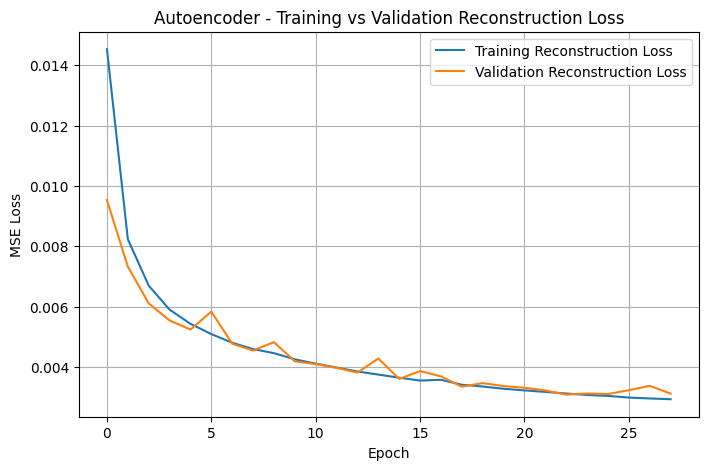

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    autoencoder_history.history["loss"],
    label="Training Reconstruction Loss"
)

plt.plot(
    autoencoder_history.history["val_loss"],
    label="Validation Reconstruction Loss"
)

plt.title("Autoencoder - Training vs Validation Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)
plt.show()

## **10.6 Autoencoder prediction**

In [53]:
reconstructed_images = autoencoder.predict(x_test)

print("Original test images shape:", x_test.shape)
print("Reconstructed images shape:", reconstructed_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Original test images shape: (10000, 32, 32, 3)
Reconstructed images shape: (10000, 32, 32, 3)


## **10.7 Representing 10 random reconstructed images**

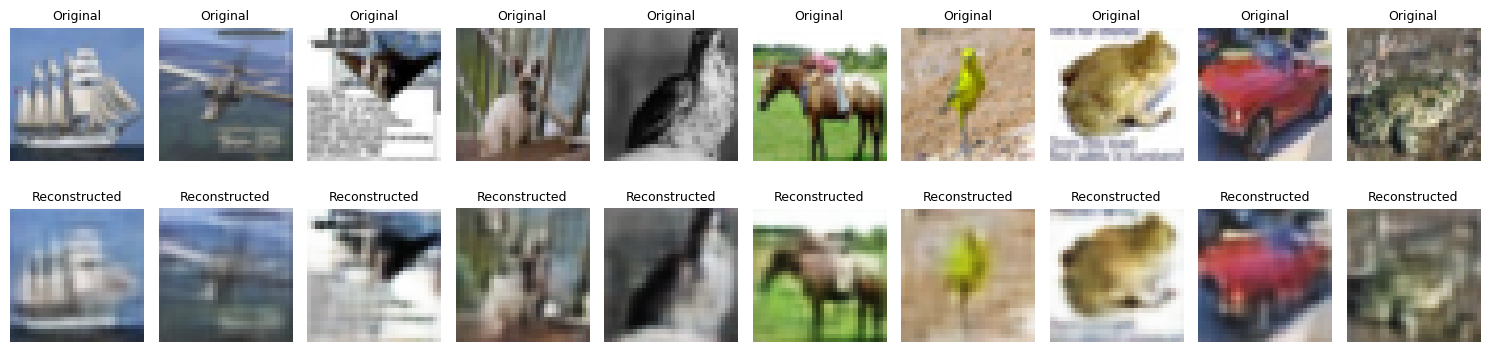

In [54]:
number_of_images = 10

random_indices = np.random.choice(
    len(x_test),
    size=number_of_images,
    replace=False
)

plt.figure(figsize=(15, 4))

for i, image_index in enumerate(random_indices):

    # Original image
    plt.subplot(2, number_of_images, i + 1)
    plt.imshow(x_test[image_index])
    plt.title("Original", fontsize=9)
    plt.axis("off")

    # Reconstructed image
    plt.subplot(2, number_of_images, i + 1 + number_of_images)
    plt.imshow(reconstructed_images[image_index])
    plt.title("Reconstructed", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## **10.8 calculate reconstruction errors**

In [55]:
ae_reconstruction_errors = np.mean(
    np.square(x_test - reconstructed_images),
    axis=(1, 2, 3)
)

print("Mean reconstruction error:", ae_reconstruction_errors.mean())
print("Minimum reconstruction error:", ae_reconstruction_errors.min())
print("Maximum reconstruction error:", ae_reconstruction_errors.max())

Mean reconstruction error: 0.003082081229276334
Minimum reconstruction error: 0.00023523600711423563
Maximum reconstruction error: 0.015321415058650324


## **10.9 representing best 10 reconstructions**

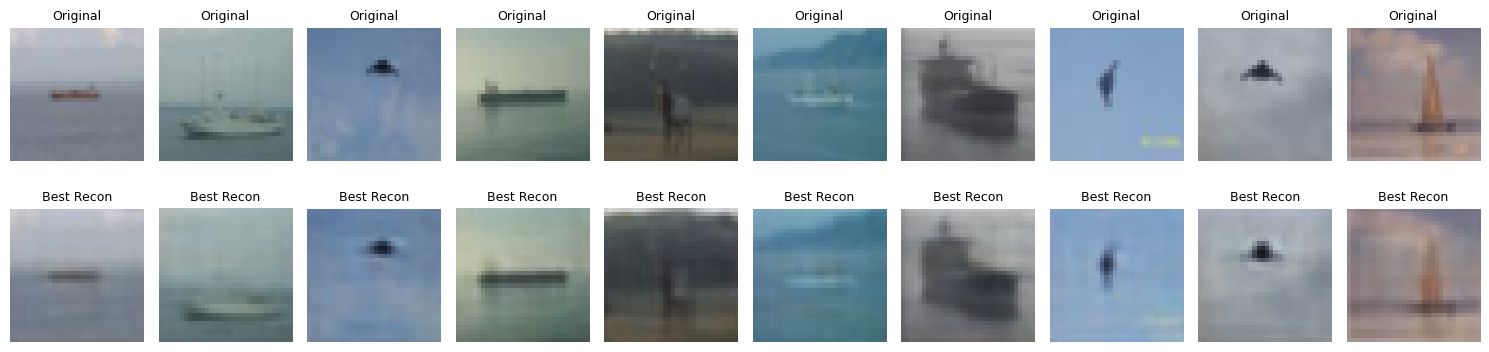

In [57]:
best_reconstruction_indices = np.argsort(ae_reconstruction_errors)[:10]

plt.figure(figsize=(15, 4))

for i, image_index in enumerate(best_reconstruction_indices):

    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[image_index])
    plt.title("Original", fontsize=9)
    plt.axis("off")

    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed_images[image_index])
    plt.title("Best Recon", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## **10.10 representing worst 10 reconstructions**

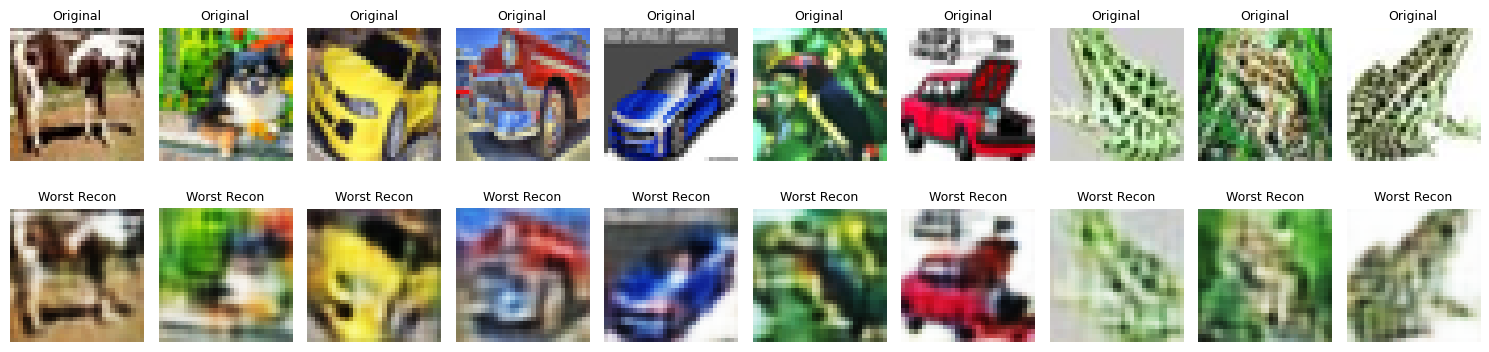

In [58]:
worst_reconstruction_indices = np.argsort(ae_reconstruction_errors)[-10:]

plt.figure(figsize=(15, 4))

for i, image_index in enumerate(worst_reconstruction_indices):

    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[image_index])
    plt.title("Original", fontsize=9)
    plt.axis("off")

    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed_images[image_index])
    plt.title("Worst Recon", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# ***11. Variational Autoencoder***

## **11.1 Defining VAE Encoder**

In [59]:
class Sampling(layers.Layer):
    """
    Sampling layer for the VAE.

    It uses z_mean and z_log_var to sample a latent vector z.
    """

    def call(self, inputs):
        z_mean, z_log_var = inputs

        batch_size = tf.shape(z_mean)[0]
        latent_dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(
            shape=(batch_size, latent_dim)
        )

        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

        return z


latent_dim = 128

In [60]:
def build_vae_encoder(latent_dim):
    encoder_inputs = layers.Input(
        shape=(32, 32, 3),
        name="encoder_input"
    )

    x = layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        strides=2,
        padding="same",
        activation="relu"
    )(encoder_inputs)

    x = layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        strides=2,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        strides=2,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Flatten()(x)

    x = layers.Dense(
        units=256,
        activation="relu"
    )(x)

    z_mean = layers.Dense(
        units=latent_dim,
        name="z_mean"
    )(x)

    z_log_var = layers.Dense(
        units=latent_dim,
        name="z_log_var"
    )(x)

    z = Sampling(name="z")([z_mean, z_log_var])

    encoder = models.Model(
        encoder_inputs,
        [z_mean, z_log_var, z],
        name="VAE_Encoder"
    )

    return encoder

## **11.2 Defining VAE decoder**

In [61]:
def build_vae_decoder(latent_dim):
    decoder_inputs = layers.Input(
        shape=(latent_dim,),
        name="decoder_input"
    )

    x = layers.Dense(
        units=4 * 4 * 128,
        activation="relu"
    )(decoder_inputs)

    x = layers.Reshape(
        target_shape=(4, 4, 128)
    )(x)

    x = layers.Conv2DTranspose(
        filters=128,
        kernel_size=(3, 3),
        strides=2,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2DTranspose(
        filters=64,
        kernel_size=(3, 3),
        strides=2,
        padding="same",
        activation="relu"
    )(x)

    x = layers.Conv2DTranspose(
        filters=32,
        kernel_size=(3, 3),
        strides=2,
        padding="same",
        activation="relu"
    )(x)

    decoder_outputs = layers.Conv2D(
        filters=3,
        kernel_size=(3, 3),
        padding="same",
        activation="sigmoid",
        name="decoder_output"
    )(x)

    decoder = models.Model(
        decoder_inputs,
        decoder_outputs,
        name="VAE_Decoder"
    )

    return decoder

In [62]:
vae_encoder = build_vae_encoder(latent_dim)
vae_decoder = build_vae_decoder(latent_dim)

vae_encoder.summary()
vae_decoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 16, 16,    │        896 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 8, 8, 64)  │     18,496 │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 4, 4, 128) │     73,856 │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2048)      │          0 │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    524,544 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │     32,896 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 128)       │     32,896 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 128)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 683,584 (2.61 MB)

 Trainable params: 683,584 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2048)           │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,899 (1.93 MB)

 Trainable params: 504,899 (1.93 MB)

 Non-trainable params: 0 (0.00 B)

## **11.3 constructing VAE model class**

In [63]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta

        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)
        return reconstructed

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + self.beta * kl_loss

        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_weights)
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                ),
                axis=(1, 2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + self.beta * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

In [64]:
vae = VAE(
    encoder=vae_encoder,
    decoder=vae_decoder,
    beta=1.0,
    name="CIFAR10_VAE"
)

vae.compile(
    optimizer=Adam(learning_rate=0.001)
)

print("VAE compiled successfully.")

VAE compiled successfully.


## **11.4 Constructing early stopping for VAE**

In [65]:
vae_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## **11.5 Fitting VAE**

In [66]:
vae_history = vae.fit(
    x_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val,),
    callbacks=[vae_early_stopping],
    verbose=1
)

Epoch 1/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - kl_loss: 9.4843 - loss: 659.9374 - reconstruction_loss: 650.4531 - val_kl_loss: 12.9705 - val_loss: 645.4080 - val_reconstruction_loss: 632.4373
Epoch 2/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 12.4930 - loss: 638.8046 - reconstruction_loss: 626.3119 - val_kl_loss: 13.1067 - val_loss: 634.0324 - val_reconstruction_loss: 620.9257
Epoch 3/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 13.5058 - loss: 633.6025 - reconstruction_loss: 620.0969 - val_kl_loss: 14.3803 - val_loss: 632.0566 - val_reconstruction_loss: 617.6762
Epoch 4/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - kl_loss: 14.2715 - loss: 631.2387 - reconstruction_loss: 616.9672 - val_kl_loss: 14.1458 - val_loss: 631.7910 - val_reconstruction_loss: 617.6454
Epoch 5/100
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - kl_loss: 14.8007 - loss: 630.1249 - reconstruction_loss: 615.3235 - val_kl_loss: 14.6900 - val_loss: 629.3486 - val_reconstruction_loss: 614

## **11.6 initial evaluation and representaion for VAE**

In [67]:
vae_test_results = vae.evaluate(
    x_test,
    verbose=0,
    return_dict=True
)

vae_test_results

{'kl_loss': 16.760522842407227,
 'loss': 627.1083984375,
 'reconstruction_loss': 610.34814453125}

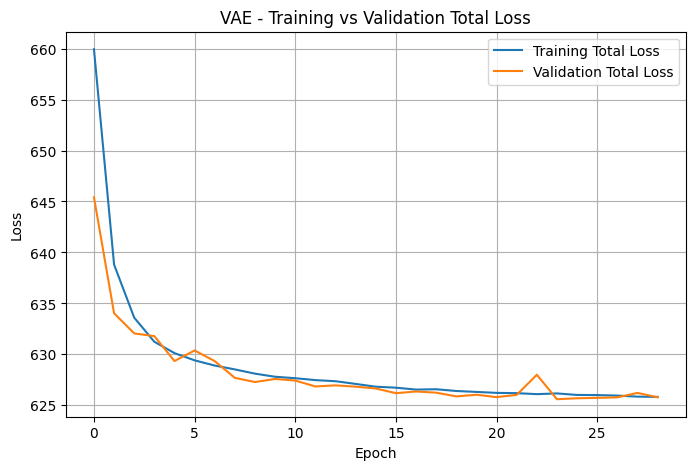

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(
    vae_history.history["loss"],
    label="Training Total Loss"
)

plt.plot(
    vae_history.history["val_loss"],
    label="Validation Total Loss"
)

plt.title("VAE - Training vs Validation Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.show()

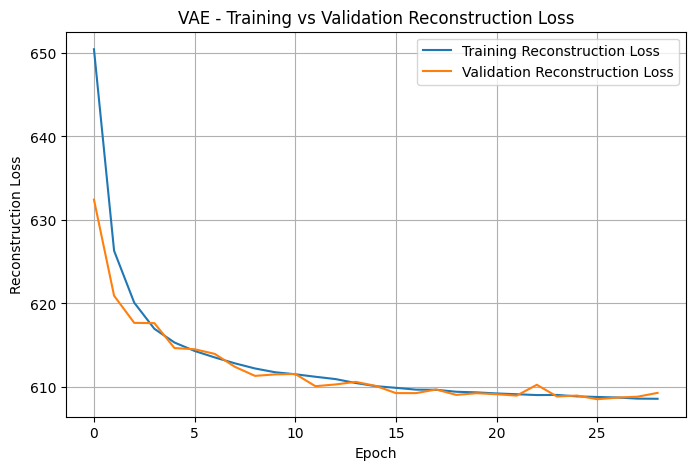

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(
    vae_history.history["reconstruction_loss"],
    label="Training Reconstruction Loss"
)

plt.plot(
    vae_history.history["val_reconstruction_loss"],
    label="Validation Reconstruction Loss"
)

plt.title("VAE - Training vs Validation Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")

plt.legend()
plt.grid(True)
plt.show()

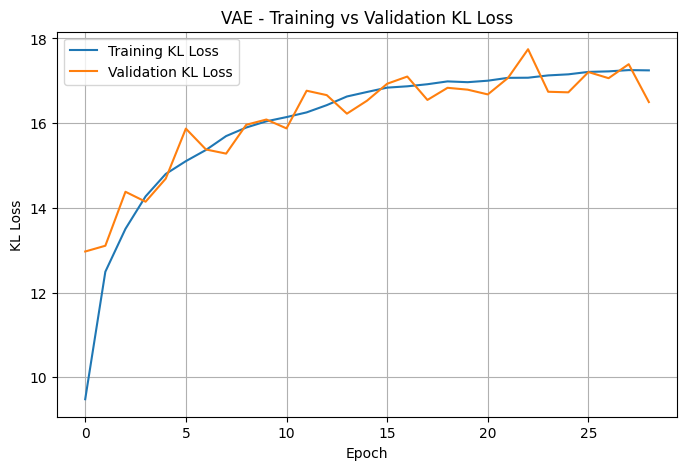

In [70]:
plt.figure(figsize=(8, 5))

plt.plot(
    vae_history.history["kl_loss"],
    label="Training KL Loss"
)

plt.plot(
    vae_history.history["val_kl_loss"],
    label="Validation KL Loss"
)

plt.title("VAE - Training vs Validation KL Loss")
plt.xlabel("Epoch")
plt.ylabel("KL Loss")

plt.legend()
plt.grid(True)
plt.show()

## **12.7 VAE prediction**

In [71]:
vae_reconstructed_images = vae.predict(x_test)

vae_reconstructed_images = np.clip(
    vae_reconstructed_images,
    0,
    1
)

print("Original images shape:", x_test.shape)
print("VAE reconstructed images shape:", vae_reconstructed_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
Original images shape: (10000, 32, 32, 3)
VAE reconstructed images shape: (10000, 32, 32, 3)


## **11.8 Representing 10 random reconstructed images**

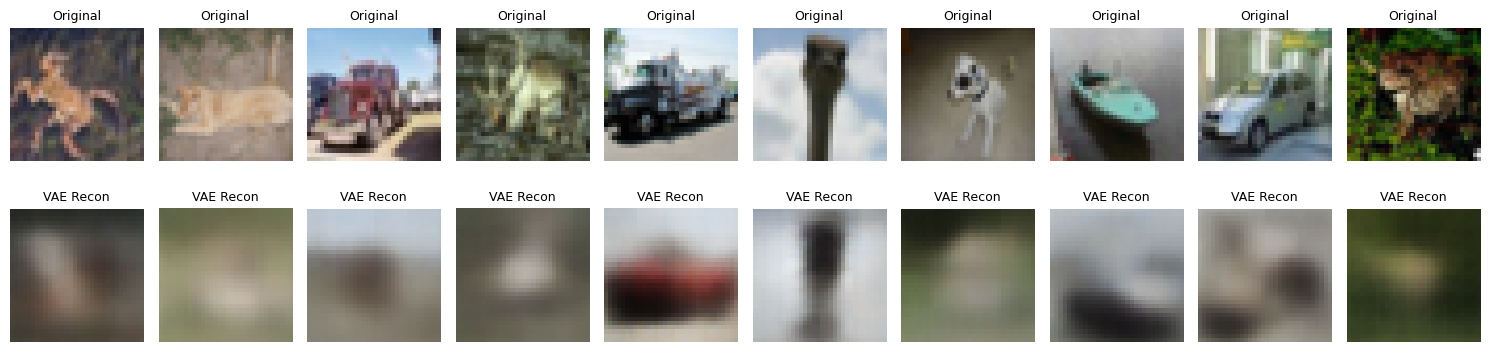

In [72]:
number_of_images = 10

random_indices = np.random.choice(
    len(x_test),
    size=number_of_images,
    replace=False
)

plt.figure(figsize=(15, 4))

for i, image_index in enumerate(random_indices):

    plt.subplot(2, number_of_images, i + 1)
    plt.imshow(x_test[image_index])
    plt.title("Original", fontsize=9)
    plt.axis("off")

    plt.subplot(2, number_of_images, i + 1 + number_of_images)
    plt.imshow(vae_reconstructed_images[image_index])
    plt.title("VAE Recon", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## **11.9 calculate VAE reconstruction errors**

In [73]:
vae_reconstruction_errors = np.mean(
    np.square(x_test - vae_reconstructed_images),
    axis=(1, 2, 3)
)

print("VAE Mean reconstruction error:", vae_reconstruction_errors.mean())
print("VAE Minimum reconstruction error:", vae_reconstruction_errors.min())
print("VAE Maximum reconstruction error:", vae_reconstruction_errors.max())

VAE Mean reconstruction error: 0.01961431031752438
VAE Minimum reconstruction error: 0.0012086255315694155
VAE Maximum reconstruction error: 0.07226592407313279


## **11.10 representing best 10 VAE reconstructions**

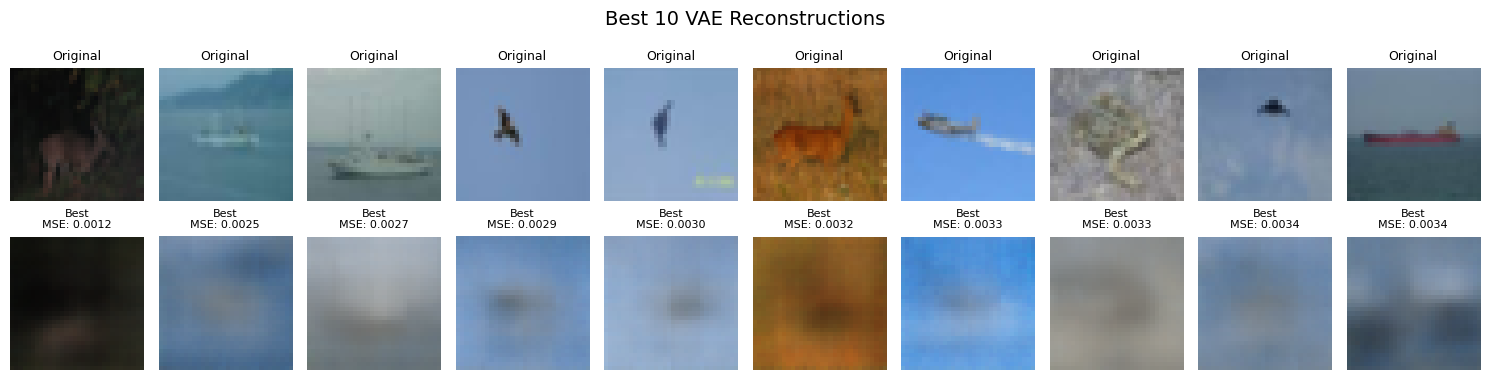

In [74]:
best_vae_indices = np.argsort(vae_reconstruction_errors)[:10]

plt.figure(figsize=(15, 4))

for i, image_index in enumerate(best_vae_indices):

    # Original image
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[image_index])
    plt.title("Original", fontsize=9)
    plt.axis("off")

    # VAE reconstructed image
    plt.subplot(2, 10, i + 11)
    plt.imshow(vae_reconstructed_images[image_index])
    plt.title(
        f"Best\nMSE: {vae_reconstruction_errors[image_index]:.4f}",
        fontsize=8
    )
    plt.axis("off")

plt.suptitle("Best 10 VAE Reconstructions", fontsize=14)
plt.tight_layout()
plt.show()

## **11.11  representing worst 10 VAE reconstructions**

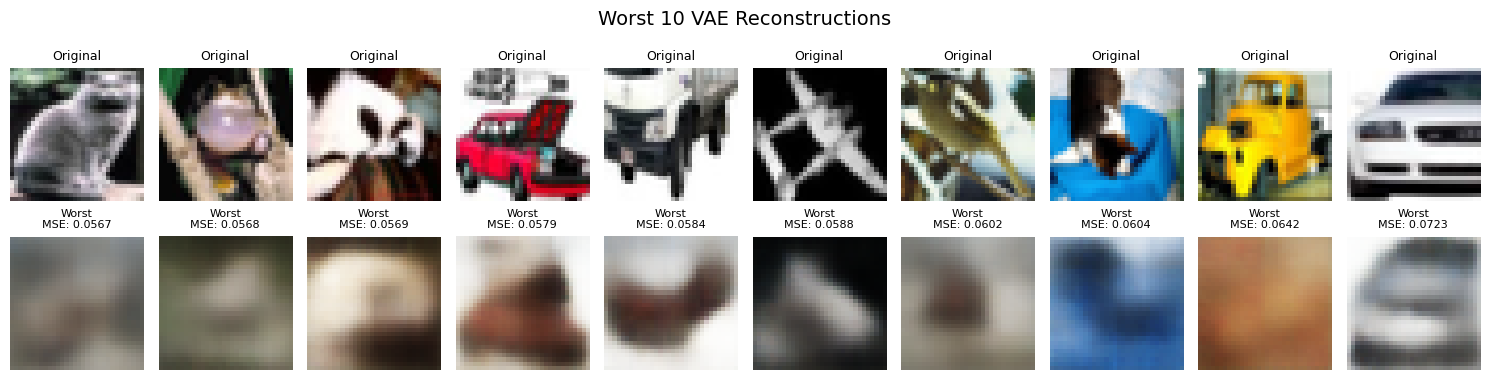

In [75]:
worst_vae_indices = np.argsort(vae_reconstruction_errors)[-10:]

plt.figure(figsize=(15, 4))

for i, image_index in enumerate(worst_vae_indices):

    # Original image
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[image_index])
    plt.title("Original", fontsize=9)
    plt.axis("off")

    # VAE reconstructed image
    plt.subplot(2, 10, i + 11)
    plt.imshow(vae_reconstructed_images[image_index])
    plt.title(
        f"Worst\nMSE: {vae_reconstruction_errors[image_index]:.4f}",
        fontsize=8
    )
    plt.axis("off")

plt.suptitle("Worst 10 VAE Reconstructions", fontsize=14)
plt.tight_layout()
plt.show()

# ***12. Reconstruction comparison***

## **12.1 Errors comparison**

In [76]:
reconstruction_comparison = pd.DataFrame({
    "Model": [
        "Convolutional Autoencoder",
        "Variational Autoencoder"
    ],
    "Mean Reconstruction Error": [
        ae_reconstruction_errors.mean(),
        vae_reconstruction_errors.mean()
    ],
    "Minimum Reconstruction Error": [
        ae_reconstruction_errors.min(),
        vae_reconstruction_errors.min()
    ],
    "Maximum Reconstruction Error": [
        ae_reconstruction_errors.max(),
        vae_reconstruction_errors.max()
    ]
})

reconstruction_comparison

,Model,Mean Reconstruction Error,Minimum Reconstruction Error,Maximum Reconstruction Error
0,Convolutional Autoencoder,0.003082,0.000235,0.015321
1,Variational Autoencoder,0.019614,0.001209,0.072266


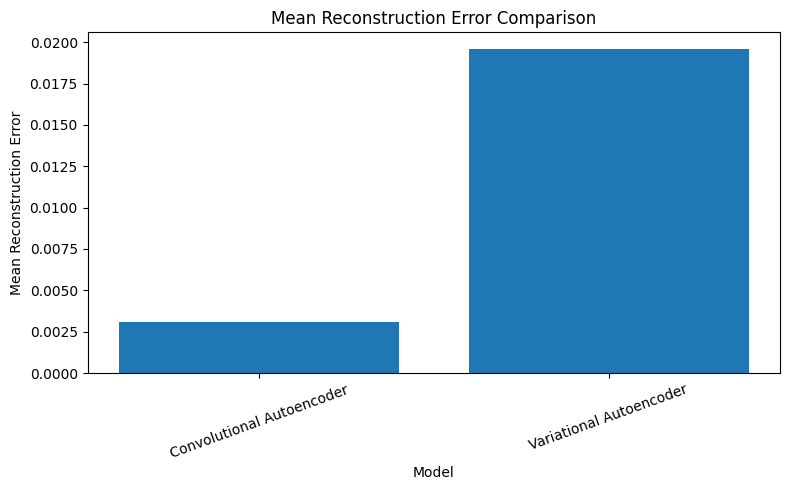

In [77]:
plt.figure(figsize=(8, 5))

plt.bar(
    reconstruction_comparison["Model"],
    reconstruction_comparison["Mean Reconstruction Error"]
)

plt.title("Mean Reconstruction Error Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Reconstruction Error")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## **12.2 random 10 images comparison**

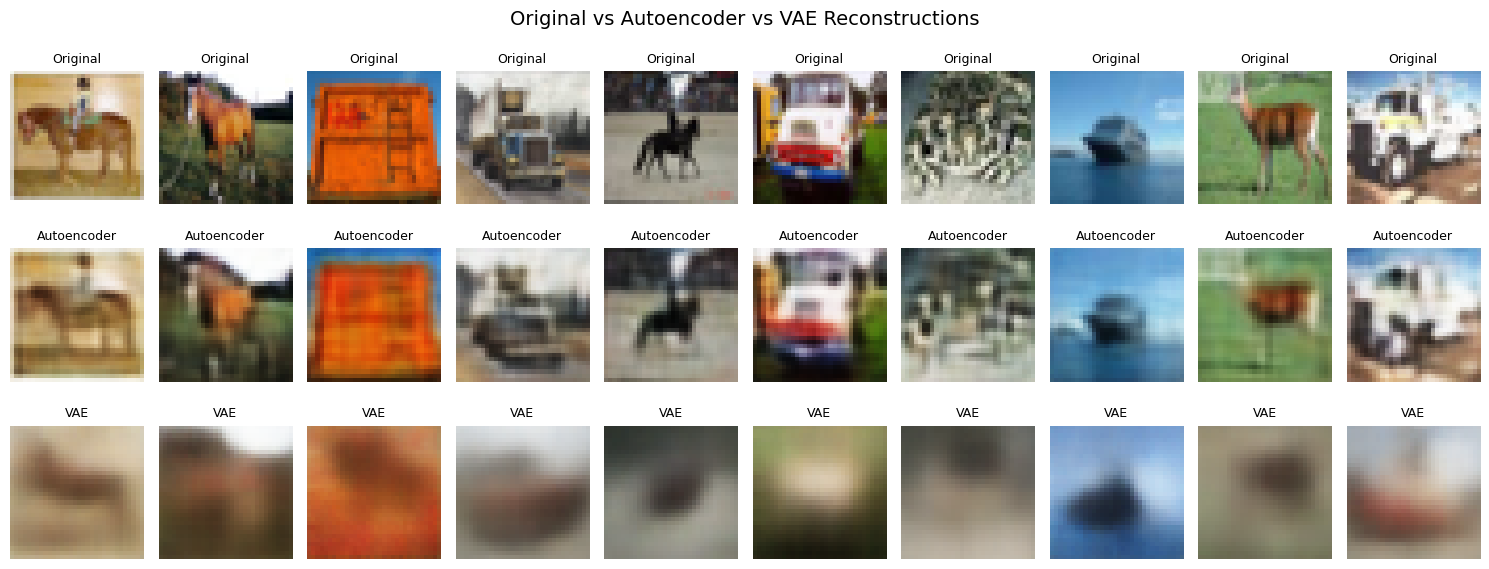

In [78]:
number_of_images = 10

random_indices = np.random.choice(
    len(x_test),
    size=number_of_images,
    replace=False
)

plt.figure(figsize=(15, 6))

for i, image_index in enumerate(random_indices):

    # Original image
    plt.subplot(3, number_of_images, i + 1)
    plt.imshow(x_test[image_index])
    plt.title("Original", fontsize=9)
    plt.axis("off")

    # Autoencoder reconstruction
    plt.subplot(3, number_of_images, i + 1 + number_of_images)
    plt.imshow(reconstructed_images[image_index])
    plt.title("Autoencoder", fontsize=9)
    plt.axis("off")

    # VAE reconstruction
    plt.subplot(3, number_of_images, i + 1 + 2 * number_of_images)
    plt.imshow(vae_reconstructed_images[image_index])
    plt.title("VAE", fontsize=9)
    plt.axis("off")

plt.suptitle("Original vs Autoencoder vs VAE Reconstructions", fontsize=14)
plt.tight_layout()
plt.show()

## **12.3 compare 10 images which got best records for Autoencoder**

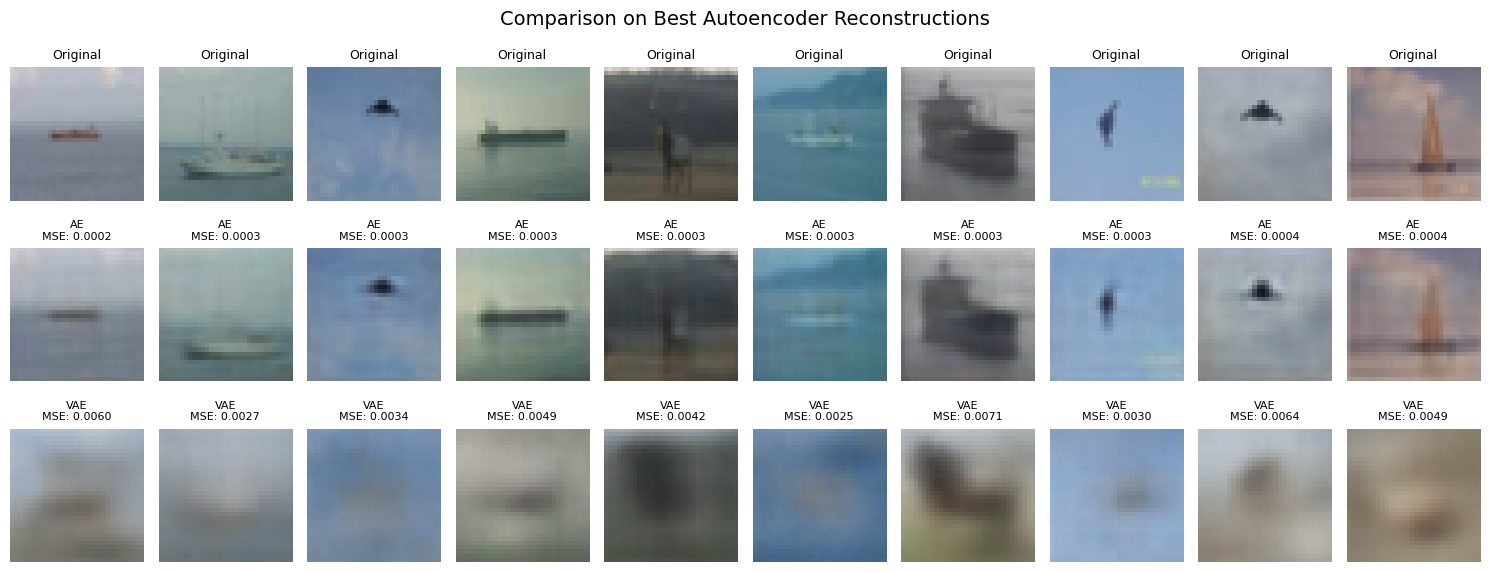

In [79]:
best_ae_indices = np.argsort(ae_reconstruction_errors)[:10]

plt.figure(figsize=(15, 6))

for i, image_index in enumerate(best_ae_indices):

    # Original
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[image_index])
    plt.title("Original", fontsize=9)
    plt.axis("off")

    # Autoencoder
    plt.subplot(3, 10, i + 11)
    plt.imshow(reconstructed_images[image_index])
    plt.title(
        f"AE\nMSE: {ae_reconstruction_errors[image_index]:.4f}",
        fontsize=8
    )
    plt.axis("off")

    # VAE
    plt.subplot(3, 10, i + 21)
    plt.imshow(vae_reconstructed_images[image_index])
    plt.title(
        f"VAE\nMSE: {vae_reconstruction_errors[image_index]:.4f}",
        fontsize=8
    )
    plt.axis("off")

plt.suptitle("Comparison on Best Autoencoder Reconstructions", fontsize=14)
plt.tight_layout()
plt.show()

## **12.4 compare 10 images which got best records for VAE**

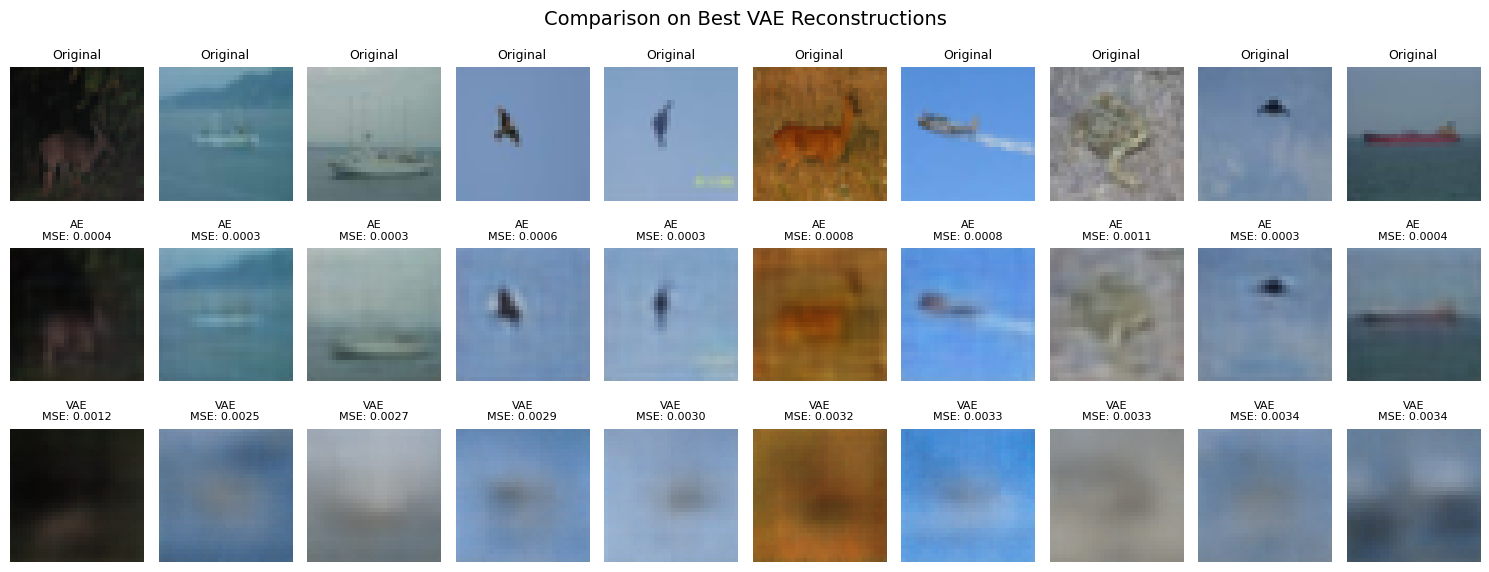

In [80]:
best_vae_indices = np.argsort(vae_reconstruction_errors)[:10]

plt.figure(figsize=(15, 6))

for i, image_index in enumerate(best_vae_indices):

    # Original
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[image_index])
    plt.title("Original", fontsize=9)
    plt.axis("off")

    # Autoencoder
    plt.subplot(3, 10, i + 11)
    plt.imshow(reconstructed_images[image_index])
    plt.title(
        f"AE\nMSE: {ae_reconstruction_errors[image_index]:.4f}",
        fontsize=8
    )
    plt.axis("off")

    # VAE
    plt.subplot(3, 10, i + 21)
    plt.imshow(vae_reconstructed_images[image_index])
    plt.title(
        f"VAE\nMSE: {vae_reconstruction_errors[image_index]:.4f}",
        fontsize=8
    )
    plt.axis("off")

plt.suptitle("Comparison on Best VAE Reconstructions", fontsize=14)
plt.tight_layout()
plt.show()

# ***13. Generative Model***

# ***14. Generated Samples***

# ***15. Final Comparison***

# ***16. Final Reflection***